### Supernova distances and redshifts: Hubble diagram for Type Ia supernovae
Measuring the cosmological relationship between distance and redshift is at the heart of the entire field of cosmology and allowed, among other things, the discovery of dark energy! At high redshifts, this is done with Type Ia Supernova which are standard (or better, standardizable) candles.

Let's recall the definition of magnitude and the distance modulus:
$$ \mu = m-M = 5\,\text{log}_{10}\biggl(\frac{d_L}{10\,\text{pc}}\biggr)$$

#### Libraries

In [1]:
! pip install astroML

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.3/134.3 kB 5.6 MB/s eta 0:00:00


In [2]:
! pip install corner

In [3]:
! pip install emcee

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 3.0 MB/s eta 0:00:00


In [4]:
! pip install dynesty

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.9/102.9 kB 3.5 MB/s eta 0:00:00


In [5]:
import matplotlib.pyplot as plt
import numpy as np

from astroML.datasets import generate_mu_z
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KernelDensity
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
from sklearn.gaussian_process import GaussianProcessRegressor

from astropy.cosmology import LambdaCDM
from scipy.integrate import quad
from scipy.stats import norm, uniform
import corner
import emcee
import dynesty

#### Exercize part 2

**Tasks**
1. First let's fit the supernova synthetic data from last time using GPR. Plot the expectation value of the fit as well as the resulting 1-sigma and 2-sigma contours. Interpret the results.
2. Then you want to clone your data. Think about the pdf of these data in $z$. Using your GPR fit, generate a set of $\mu$ measurements that respects the statistical properties of the data you were given.

In [6]:
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS
z_grid = np.linspace(0.01, 2, 1000)

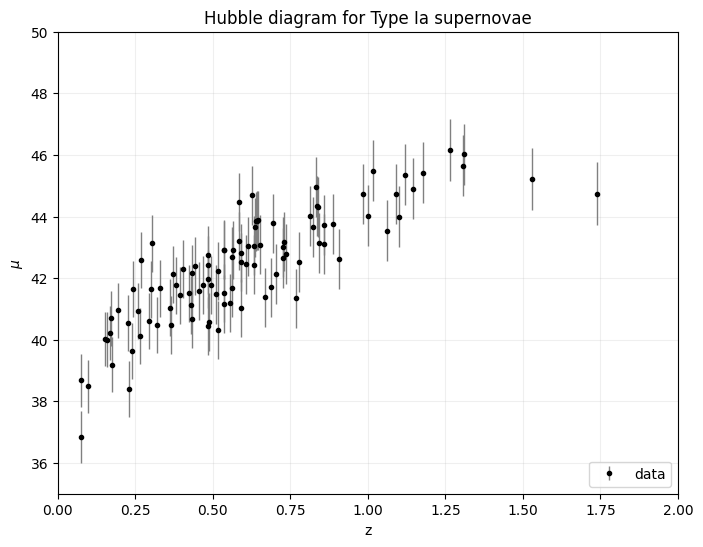

In [7]:
plt.figure(figsize=(8, 6))
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.title("Hubble diagram for Type Ia supernovae")
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)
plt.grid(alpha=0.2)
plt.show()

In [8]:
# remember sklearn requires format (n_samples, n_features)

# Training datapoints: our data
X = np.array([z_sample]).T
y = np.array(mu_sample)
y_err = np.array(dmu)
# Test datapoints: new data
X_grid = np.array([z_grid]).T

In [9]:
print(X.shape)
print(X_grid.shape)
print(y.shape)

(100, 1)
(1000, 1)
(100,)


**GPR**

Kernel choice for the GPR:
$$k(x,x'|\sigma_k,h)=\sigma_k^2 \mbox{exp}\left\{-\frac{(x-x')^2}{2h^2}\right\}$$
where the constant $\sigma_k$ of the Constant Kernel and the bandwidth $h$ of the RBF Kernel are tuned with the already implemented optimization algorithm.

In [10]:
kernel = ConstantKernel(constant_value=1.0, constant_value_bounds=(1e-4, 1e4)) * RBF(length_scale=1.0, length_scale_bounds=(1e-3, 1e3)) # start with some default values
gpr = GaussianProcessRegressor(kernel=kernel, alpha=y_err**2, n_restarts_optimizer=10) # use the implemented kernel optimization
gpr.fit(X, y)
print("Optimized kernel:", gpr.kernel_)
mu_fit, sigma_fit = gpr.predict(X_grid, return_std=True)

Optimized kernel: 30.7**2 * RBF(length_scale=3.9)


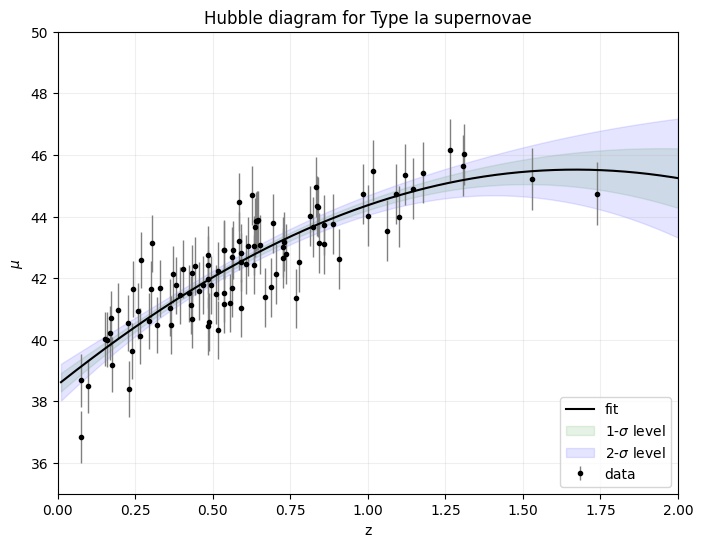

In [11]:
plt.figure(figsize=(8, 6))
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label="data")
plt.plot(z_grid, mu_fit, '-k', label="fit")
plt.fill_between(z_grid, mu_fit - sigma_fit, mu_fit + sigma_fit, alpha=0.1, color='g', label=r'1-$\sigma$ level')
plt.fill_between(z_grid, mu_fit - 2*sigma_fit, mu_fit + 2*sigma_fit, alpha=0.1, color='b', label=r'2-$\sigma$ level')
plt.title("Hubble diagram for Type Ia supernovae")
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)
plt.grid(alpha=0.2)
plt.show()

We can notice that the high-redshift end is less constrained than the low-redshift end with the collected data.

**KDE and cloning data**
- Draw new $z$ from a pdf inferred from the density of the known data using KDE
- Given $\mu = f(z|\underline{\theta})$, with GPR you can find new $\mu$ from new $z$

In [12]:
b_range = np.logspace(-2, 1, 100) # Test different bandwidth values
K = 20 # Do 20-fold cross validation
CVgrid = GridSearchCV(KernelDensity(), {'bandwidth': b_range}, cv=K) # Try each bandwidth with K-folds
CVgrid.fit(X) # Fit the data
b_opt = CVgrid.best_params_['bandwidth']
print("{:.3f}".format(b_opt))

0.132


In [13]:
# grid search CV results table
results = CVgrid.cv_results_
print(results.keys())

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_bandwidth', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'split5_test_score', 'split6_test_score', 'split7_test_score', 'split8_test_score', 'split9_test_score', 'split10_test_score', 'split11_test_score', 'split12_test_score', 'split13_test_score', 'split14_test_score', 'split15_test_score', 'split16_test_score', 'split17_test_score', 'split18_test_score', 'split19_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score'])


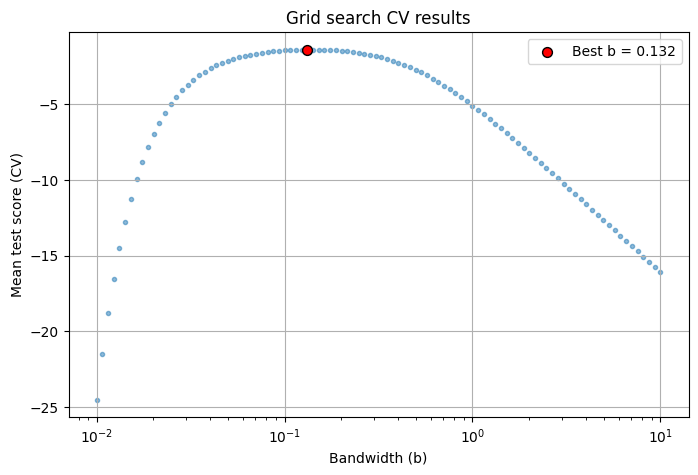

In [14]:
# tested b values
b_values = results['param_bandwidth'].data
# mean test score for each b
mean_scores = results['mean_test_score']
# best b value
best_b = CVgrid.best_params_['bandwidth']
best_score = CVgrid.best_score_

plt.figure(figsize=(8, 5))
plt.plot(b_values, mean_scores, marker='.', linestyle="", alpha=0.5, zorder=1)
plt.scatter(best_b, best_score, color='red', s=50, edgecolors="k", label=f"Best b = {best_b:.3f}", zorder=2)
plt.xlabel("Bandwidth (b)")
plt.ylabel("Mean test score (CV)")
plt.xscale('log')
plt.title("Grid search CV results")
plt.grid(True)
plt.legend()
plt.show()

In [15]:
kde_z = KernelDensity(bandwidth=b_opt, kernel="gaussian")
kde_z.fit(X)
log_pdf_z = kde_z.score_samples(X_grid) # sklearn returns log(density)
pdf_z = np.exp(log_pdf_z)

In [16]:
# making variable-width bin sizes that have the same number of objects in each bin.
bins10 = np.append(np.sort(z_sample)[::10], np.max(z_sample))

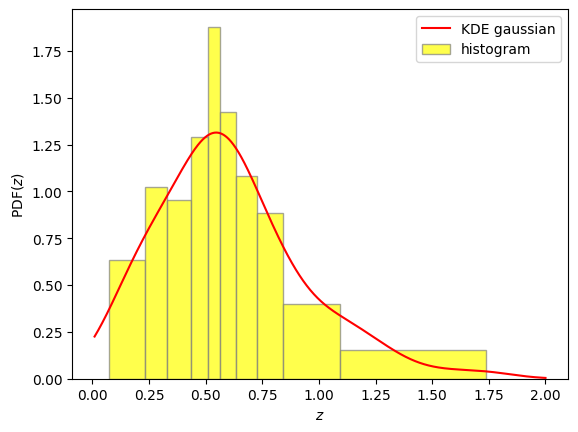

In [17]:
plt.plot(z_grid, pdf_z, "-r", label="KDE gaussian")
plt.hist(z_sample, bins=bins10, density=True, edgecolor="gray", color="yellow", alpha=0.7, label="histogram")
plt.xlabel(r"$z$")
plt.ylabel(r"PDF($z$)")
plt.legend(loc="upper right")
plt.show()

In [18]:
N_cloned = 10000
new_z_sample = kde_z.sample(N_cloned)
print(new_z_sample.shape)

(10000, 1)


When you ask for a prediction at a new point, GPR doesn’t just give you a number, but it gives you **mean and standard deviation of the gaussian posterior distribution** the algorithm computes to tell you the expected value at the new point and how confident the model is in that prediction.

In [19]:
new_mu, new_sigma = gpr.predict(new_z_sample, return_std=True)
new_mu_sample = []
for i in range(N_cloned):
  new_mu_sample.append(np.random.normal(new_mu[i], new_sigma[i]))
new_mu_sample = np.array(new_mu_sample)

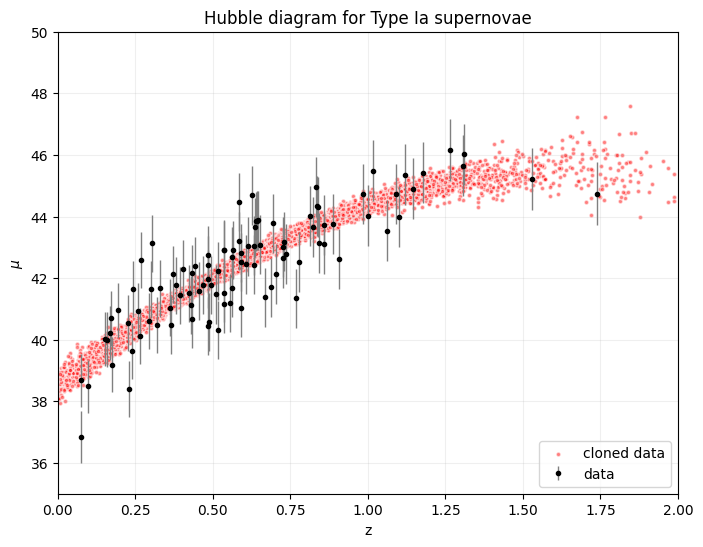

In [20]:
plt.figure(figsize=(8, 6))
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label="data")
plt.scatter(new_z_sample, new_mu_sample, color="red", edgecolors="white", s=10, label='cloned data', alpha=0.5)
plt.title("Hubble diagram for Type Ia supernovae")
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)
plt.grid(alpha=0.2)
plt.show()

In [21]:
# making variable-width bin sizes that have the same number of objects in each bin.
bins500 = np.append(np.sort(new_z_sample.flatten())[::500], np.max(new_z_sample))

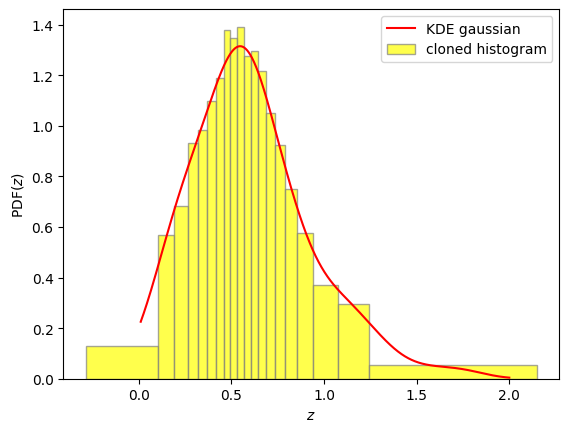

In [22]:
plt.plot(z_grid, pdf_z, "-r", label="KDE gaussian")
plt.hist(new_z_sample, bins=bins500, density=True, edgecolor="gray", color="yellow", alpha=0.7, label="cloned histogram")
plt.xlabel(r"$z$")
plt.ylabel(r"PDF($z$)")
plt.legend(loc="upper right")
plt.show()

#### Exercize part 3

We now have a suite of data-driven predictive models for our supernova dataset (from polynomials to GPR).
But for this case we have a physical theory which is the $\Lambda \mbox{CDM}$ cosmological model. We can do a parametric fit.

**Tasks**
1. First, write down the predicted relationship between the distance modulus and the redshift, assuming the $\Lambda \mbox{CDM}$ cosmology and a flat Universe.
2. Fit the model to the data, setting up a Bayesian framework and using MCMC for example.
3. What are the measured parameters values? What are their errors (credible regions)? Are they correlated?
4. How would a model without dark energy perform? Do these data contain enough evidence of dark energy? This is a model selection problem, use nested sampling for example.




In [23]:
# This is the underlying true relationship coming from the flat LambdaCDM cosmology
cosmo = LambdaCDM(H0=71, Om0=0.27, Ode0=1-0.27)
z_grid = np.linspace(0.01, 2, 1000)
mu_true = cosmo.distmod(z_grid)

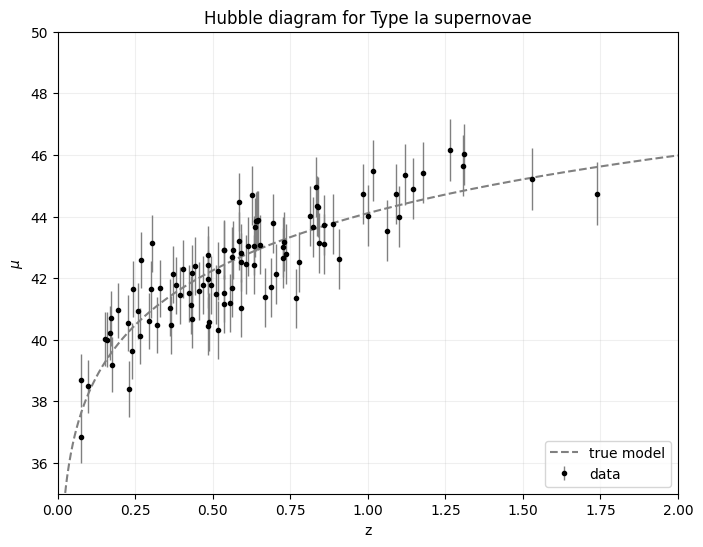

In [24]:
plt.figure(figsize=(8, 6))
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(z_grid, mu_true, '--', c='gray',label='true model')
plt.title("Hubble diagram for Type Ia supernovae")
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)
plt.grid(alpha=0.2)
plt.show()

In [25]:
# Instead of using astropy, try to define manually the model

# only for vectorial data
# pars = (H0[km/s/Mpc], Om0) correct order
def model(data, pars):
  result = []
  for z in data:
    integrand = lambda t: 1/np.sqrt(pars[1]*(1+t)**3 + (1-pars[1]))
    dl = (3e5*(1+z)/pars[0])*quad(integrand, 0, z)[0] # luminosity distance in Mpc
    result.append(5*np.log10((dl*1e6)/10)) # dl from Mpc to pc
  return np.array(result)

In [26]:
mu_model = model(z_grid, (71, 0.27))

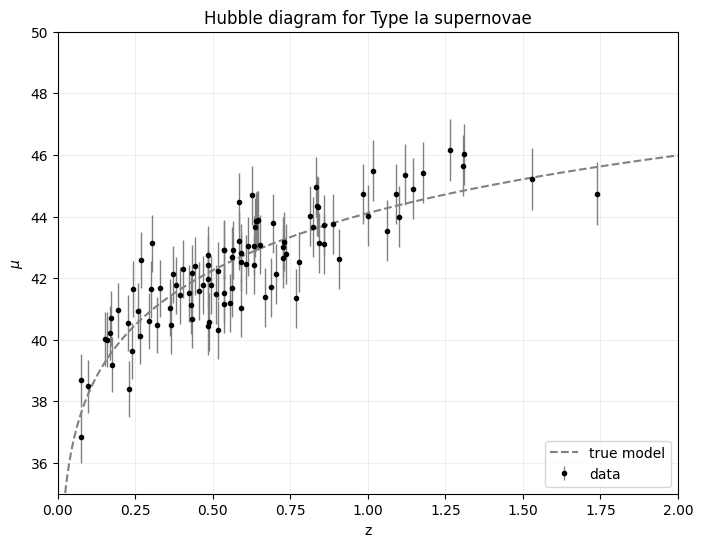

In [27]:
plt.figure(figsize=(8, 6))
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
plt.plot(z_grid, mu_model, '--', c='gray',label='true model')
plt.title("Hubble diagram for Type Ia supernovae")
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)
plt.grid(alpha=0.2)
plt.show()

**Bayesian inference and an MCMC algorithm**

In [28]:
# Let's assume gaussian uncertainties
def logLikelihood(pars, x, y, yerr):
    y_model = model(x, pars)
    if np.any(np.isnan(y_model)) or np.any(~np.isfinite(y_model)):
      return -np.inf
    else:
      return -0.5 * np.sum(((y - y_model) / yerr)**2 + np.log(2 * np.pi * yerr**2))

In [29]:
# Let's assume uninformative priors for a data-dominated inference
def Prior(pars):
    prior_H0 = uniform.pdf(pars[0], loc=50.0, scale=50.0)
    prior_Om0 = uniform.pdf(pars[1], loc=0.0, scale=1.0)
    return  prior_H0 * prior_Om0

In [30]:
# Notice that emcee wants ln of posterior pdf
def logPosterior(pars, x, y, yerr):
    lp = np.log(Prior(pars))
    if not np.isfinite(lp):
      return -np.inf
    else:
      return logLikelihood(pars, x, y, yerr) + lp

In [31]:
# Now let's run an MCMC algorithm
# emcee combines multiple "walkers", each of which is its own MCMC chain. The number of trace results will be nwalkers x nsteps.
ndim = 2  # number of parameters in the model
nwalkers = 6  # number of MCMC walkers (at least twice the number of dimensions)
nsteps = 50000 # number of MCMC steps to take **for each walker**

# initialize theta (inizializzare i camminatori attorno a un punto scelto a occhio nello spazio dei parametri,
# ma con una piccola variazione casuale, così non partono tutti esattamente dallo stesso).
np.random.seed(0)
starting_guesses = np.array([71, 0.27])+1e-1*np.random.randn(nwalkers, ndim)

# the function call where all the work happens:
sampler = emcee.EnsembleSampler(nwalkers, ndim, logPosterior, args=(z_sample, mu_sample, dmu))
sampler.run_mcmc(starting_guesses, nsteps, progress=True);

print("done")

  0%|          | 0/50000 [00:00<?, ?it/s]/tmp/ipython-input-1941332794.py:3: RuntimeWarning: divide by zero encountered in log
  lp = np.log(Prior(pars))
100%|██████████| 50000/50000 [25:51<00:00, 32.23it/s]

done


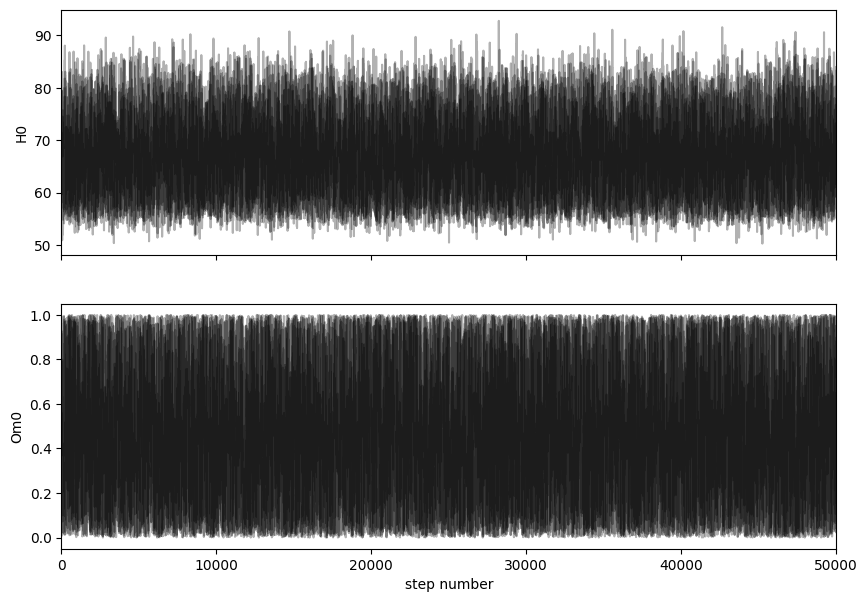

In [32]:
fig, axes = plt.subplots(2, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["H0","Om0"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
axes[-1].set_xlabel("step number");

In [33]:
# Now take one point every autocorrelation lenght
tau = sampler.get_autocorr_time()
print(tau)

[46.89749653 48.56733745]


In [34]:
flat_samples = sampler.get_chain(discard=int(nsteps/10), thin=int(np.ceil(np.max(tau))), flat=True)
print(flat_samples.shape)

(5508, 2)


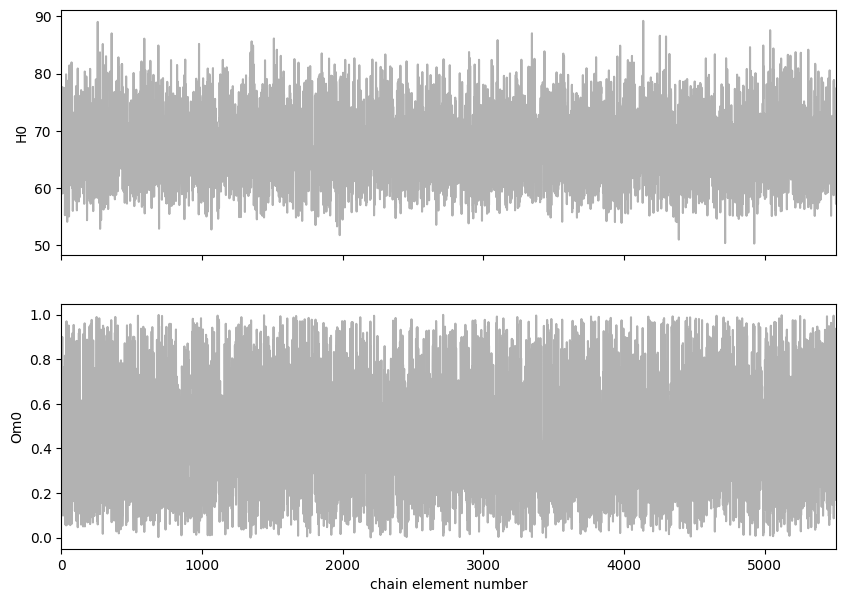

In [35]:
fig, axes = plt.subplots(2, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(flat_samples[:, i], "k", alpha=0.3)
    ax.set_xlim(0, len(flat_samples))
    ax.set_ylabel(labels[i])
axes[-1].set_xlabel("chain element number");

In [36]:
H0_q05, H0_q50, H0_q95 = np.percentile(flat_samples[:, 0], [5, 50, 95])
Om0_q05, Om0_q50, Om0_q95 = np.percentile(flat_samples[:, 1], [5, 50, 95])

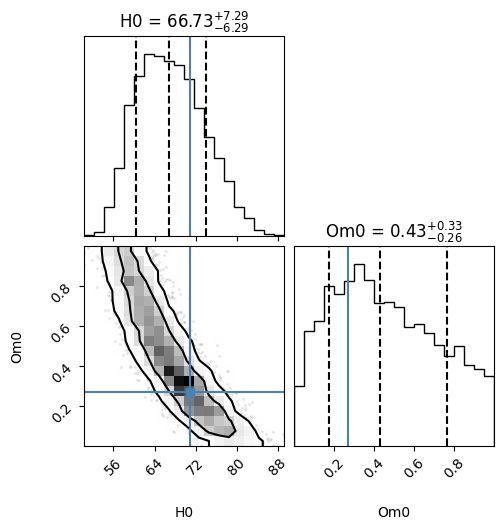

In [37]:
fig = corner.corner(flat_samples, labels=labels, quantiles=(0.16, 0.50, 0.84), levels=(0.68, 0.95), truths=(71, 0.27), show_titles=True)
plt.show()

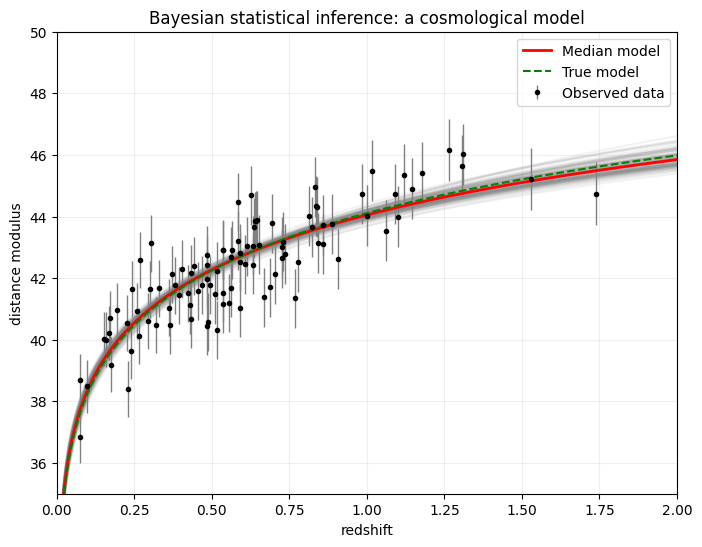

In [38]:
x_fit = np.linspace(0.01, 2, 1000)
y_median = model(x_fit, [H0_q50, Om0_q50])

plt.figure(figsize=(8, 6))
# Plot the observed data
plt.errorbar(z_sample, mu_sample, yerr=dmu, fmt='.k', ecolor="gray", lw=1, label="Observed data")
# Plot a few random samples from posterior
for s in flat_samples[np.random.choice(len(flat_samples), size=100, replace=False)]:
  plt.plot(x_fit, model(x_fit, s), color='gray', alpha=0.1)
# Plot the median model
plt.plot(x_fit, y_median, lw=2, color="red", label="Median model")
# Plot the true model
plt.plot(z_grid, mu_true, '--', c='green', label="True model")

plt.xlabel("redshift")
plt.ylabel("distance modulus")
plt.title("Bayesian statistical inference: a cosmological model")
plt.legend()
plt.xlim(0, 2)
plt.ylim(35, 50)
plt.grid(alpha=0.2)
plt.show()

In [39]:
from IPython.display import display, Math

In [40]:
# Printing parameters estimation with 90% confidence regions
output_lines = [r"\begin{aligned}"]
for i, label in enumerate(labels):
    p05, p50, p95 = np.percentile(flat_samples[:, i], [5, 50, 95])
    lower = p50 - p05
    upper = p95 - p50
    output_lines.append(fr"\text{{{label}}} &= {p50:.2f}^{{+{upper:.2f}}}_{{-{lower:.2f}}} \\")
output_lines.append(r"\end{aligned}")

latex_block = "\n".join(output_lines)
display(Math(latex_block))

<IPython.core.display.Math object>

**Bayesian inference and nested sampling for model comparison**

In [47]:
# Perform a nested sampling algorithm for both models

from dynesty import plotting as dyplot
from dynesty import utils as dyfunc

In [44]:
# Be careful with how you transform your parameter space into a unit hypercube for the nested sampling priors
def prior_transform(vec_u):
    prior_H0 = 50.0 + 50.0 * vec_u[0]        # H0 ~ Uniform(50, 100)
    prior_Om0 = 0.0 + 1.0 * vec_u[1]         # Om0 ~ Uniform(0, 1)
    return np.array([prior_H0, prior_Om0])

In [46]:
# "Static" nested sampling
sampler_M1 = dynesty.NestedSampler(logLikelihood, prior_transform, ndim=2, logl_args=(z_sample, mu_sample, dmu))
sampler_M1.run_nested(print_progress=True)
results_M1 = sampler_M1.results

1531it [00:56, 26.99it/s, +500 | bound: 0 | nc: 1 | ncall: 11662 | eff(%): 18.196 | loglstar:   -inf < -132.815 <    inf | logz: -135.015 +/-  0.041 | dlogz:  0.001 >  0.509]


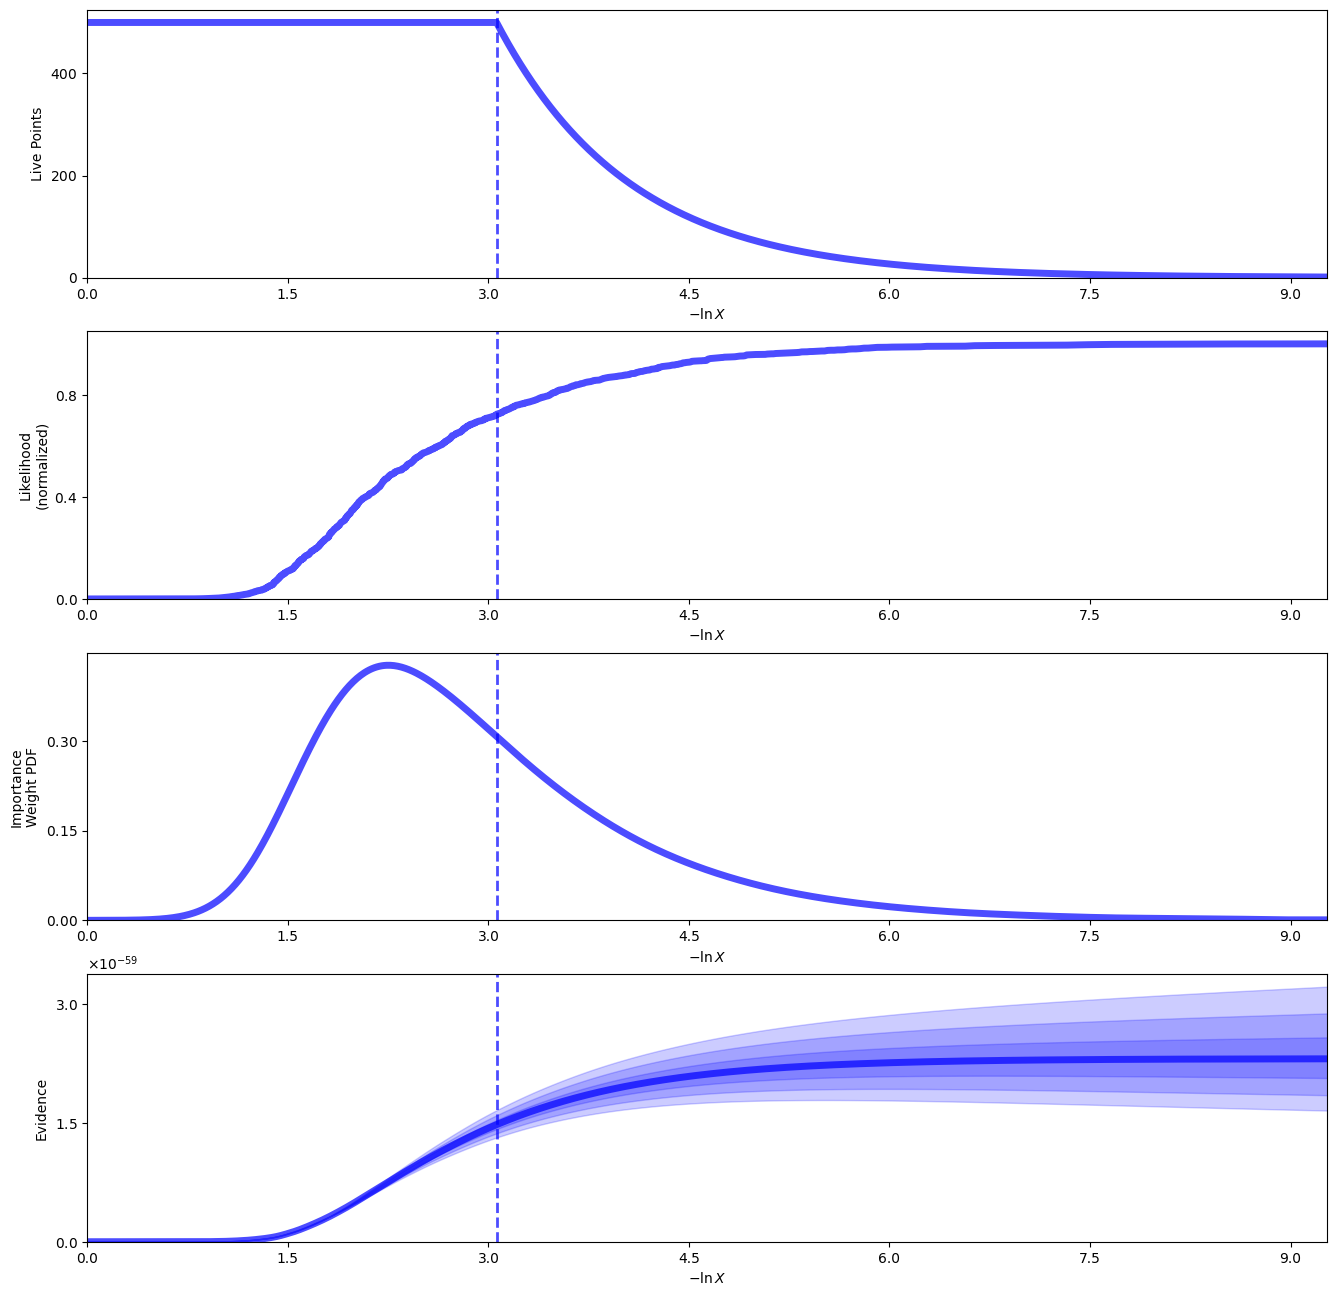

In [48]:
# Plot a summary of the run
r1fig, r1axes = dyplot.runplot(results_M1)

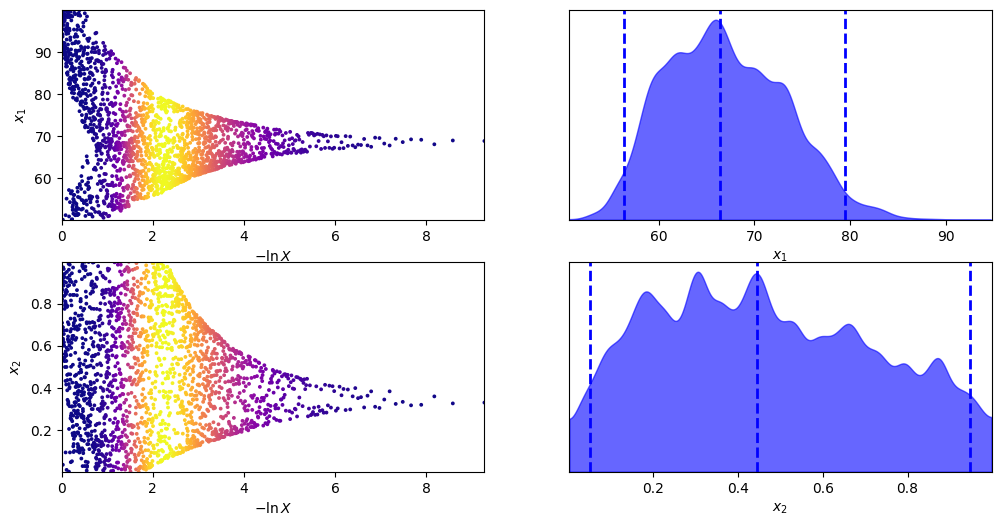

In [49]:
# Plot parameter traces and 1-D marginalized posteriors.
# On the left panels, you'll see that the live points started out scattered across the prior volume, then move inwards as the sampler climbs the likelihood
t1fig, t1axes = dyplot.traceplot(results_M1)

In [51]:
# Extract sampling results
samples_M1 = results_M1.samples  # samples
weights_M1 = np.exp(results_M1.logwt - results_M1.logz[-1])  # normalized weights

evidence_M1 = results_M1.logz[-1] # evidence
print(f"Bayesian evidence: {np.exp(evidence_M1): .3e}")

# Compute quantiles
quantiles_M1 = [dyfunc.quantile(samps, [0.05, 0.16, 0.84, 0.95], weights=weights_M1) for samps in samples_M1.T]

# Compute medians
medians_M1 = [dyfunc.quantile(samps, 0.5, weights=weights_M1) for samps in samples_M1.T]
medians_M1 = np.array(medians_M1).flatten()

print("ROBUST PARAMETERS ESTIMATION (using 90% parameter credible regions):")
print(f"H0 = {medians_M1[0]: .1f} +{quantiles_M1[0][3]-medians_M1[0]: .1f} -{medians_M1[0]-quantiles_M1[0][0]: .1f}")
print(f"Om0 = {medians_M1[1]: .2f} +{quantiles_M1[1][3]-medians_M1[1]: .2f} -{medians_M1[1]-quantiles_M1[1][0]: .2f}")

# Compute weighted mean and covariance
mean_M1, cov_M1 = dyfunc.mean_and_cov(samples_M1, weights_M1)
print("MEAN AND STD PARAMETERS ESTIMATION:")
print(f"H0 = {mean_M1[0]: .1f} +-{np.sqrt(cov_M1[0,0]): .1f}")
print(f"Om0 = {mean_M1[1]: .2f} +-{np.sqrt(cov_M1[1,1]): .2f}")

Bayesian evidence:  2.311e-59
ROBUST PARAMETERS ESTIMATION (using 90% parameter credible regions):
H0 =  66.5 + 11.2 - 8.7
Om0 =  0.44 + 0.46 - 0.36
MEAN AND STD PARAMETERS ESTIMATION:
H0 =  67.0 +- 6.2
Om0 =  0.47 +- 0.26


In [52]:
# dynesty can postprocess results to produce equally weighted samples.
# This is useful if you then want to used them in another package (for instance corner) that cannot deal with weights.
# Resample weighted samples
samples_equal_M1 = dyfunc.resample_equal(samples_M1, weights_M1)

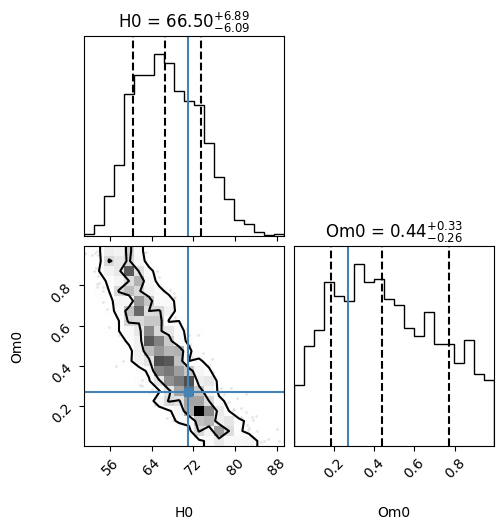

In [53]:
fig = corner.corner(samples_equal_M1, labels=labels, quantiles=(0.16, 0.50, 0.84), levels=(0.68, 0.95), truths=(71, 0.27), show_titles=True)
plt.show()

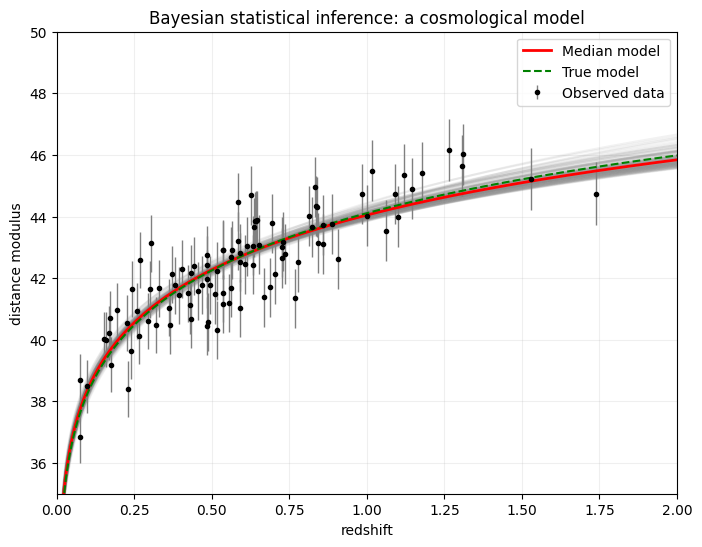

In [54]:
x_fit_M1 = np.linspace(0.01, 2, 1000)
y_median_M1 = model(x_fit_M1, medians_M1)

plt.figure(figsize=(8, 6))
# Plot the observed data
plt.errorbar(z_sample, mu_sample, yerr=dmu, fmt='.k', ecolor="gray", lw=1, label="Observed data")
# Plot a few random samples from posterior
for s in samples_equal_M1[np.random.choice(len(samples_equal_M1), size=100, replace=False)]:
  plt.plot(x_fit_M1, model(x_fit_M1, s), color='gray', alpha=0.1)
# Plot the median model
plt.plot(x_fit_M1, y_median_M1, lw=2, color="red", label="Median model")
# Plot the true model
plt.plot(z_grid, mu_true, '--', c='green', label="True model")

plt.xlabel("redshift")
plt.ylabel("distance modulus")
plt.title("Bayesian statistical inference: a cosmological model")
plt.legend()
plt.xlim(0, 2)
plt.ylim(35, 50)
plt.grid(alpha=0.2)
plt.show()

In [41]:
# Now let's assume we don't have dark energy in our model (so Om0=1)

# only for vectorial data
# pars = (H0[km/s/Mpc])
def new_model(data, pars):
  result = []
  for z in data:
    integrand = lambda t: 1/np.sqrt((1+t)**3)
    dl = (3e5*(1+z)/pars[0])*quad(integrand, 0, z)[0] # luminosity distance in Mpc
    result.append(5*np.log10((dl*1e6)/10)) # dl from Mpc to pc
  return np.array(result)

In [42]:
# Let's assume gaussian uncertainties
def new_logLikelihood(pars, x, y, yerr):
    y_model = new_model(x, pars)
    if np.any(np.isnan(y_model)) or np.any(~np.isfinite(y_model)):
      return -np.inf
    else:
      return -0.5 * np.sum(((y - y_model) / yerr)**2 + np.log(2 * np.pi * yerr**2))

In [55]:
# Be careful with how you transform your parameter space into a unit hypercube for the nested sampling priors
def new_prior_transform(vec_u):
    prior_H0 = 50.0 + 50.0 * vec_u[0]        # H0 ~ Uniform(50, 100)
    return np.array([prior_H0])

In [56]:
# "Static" nested sampling
sampler_M2 = dynesty.NestedSampler(new_logLikelihood, new_prior_transform, ndim=1, logl_args=(z_sample, mu_sample, dmu))
sampler_M2.run_nested(print_progress=True)
results_M2 = sampler_M2.results

1459it [00:40, 36.30it/s, +500 | bound: 0 | nc: 1 | ncall: 10952 | eff(%): 18.743 | loglstar:   -inf < -133.530 <    inf | logz: -135.540 +/-  0.028 | dlogz:  0.001 >  0.509]


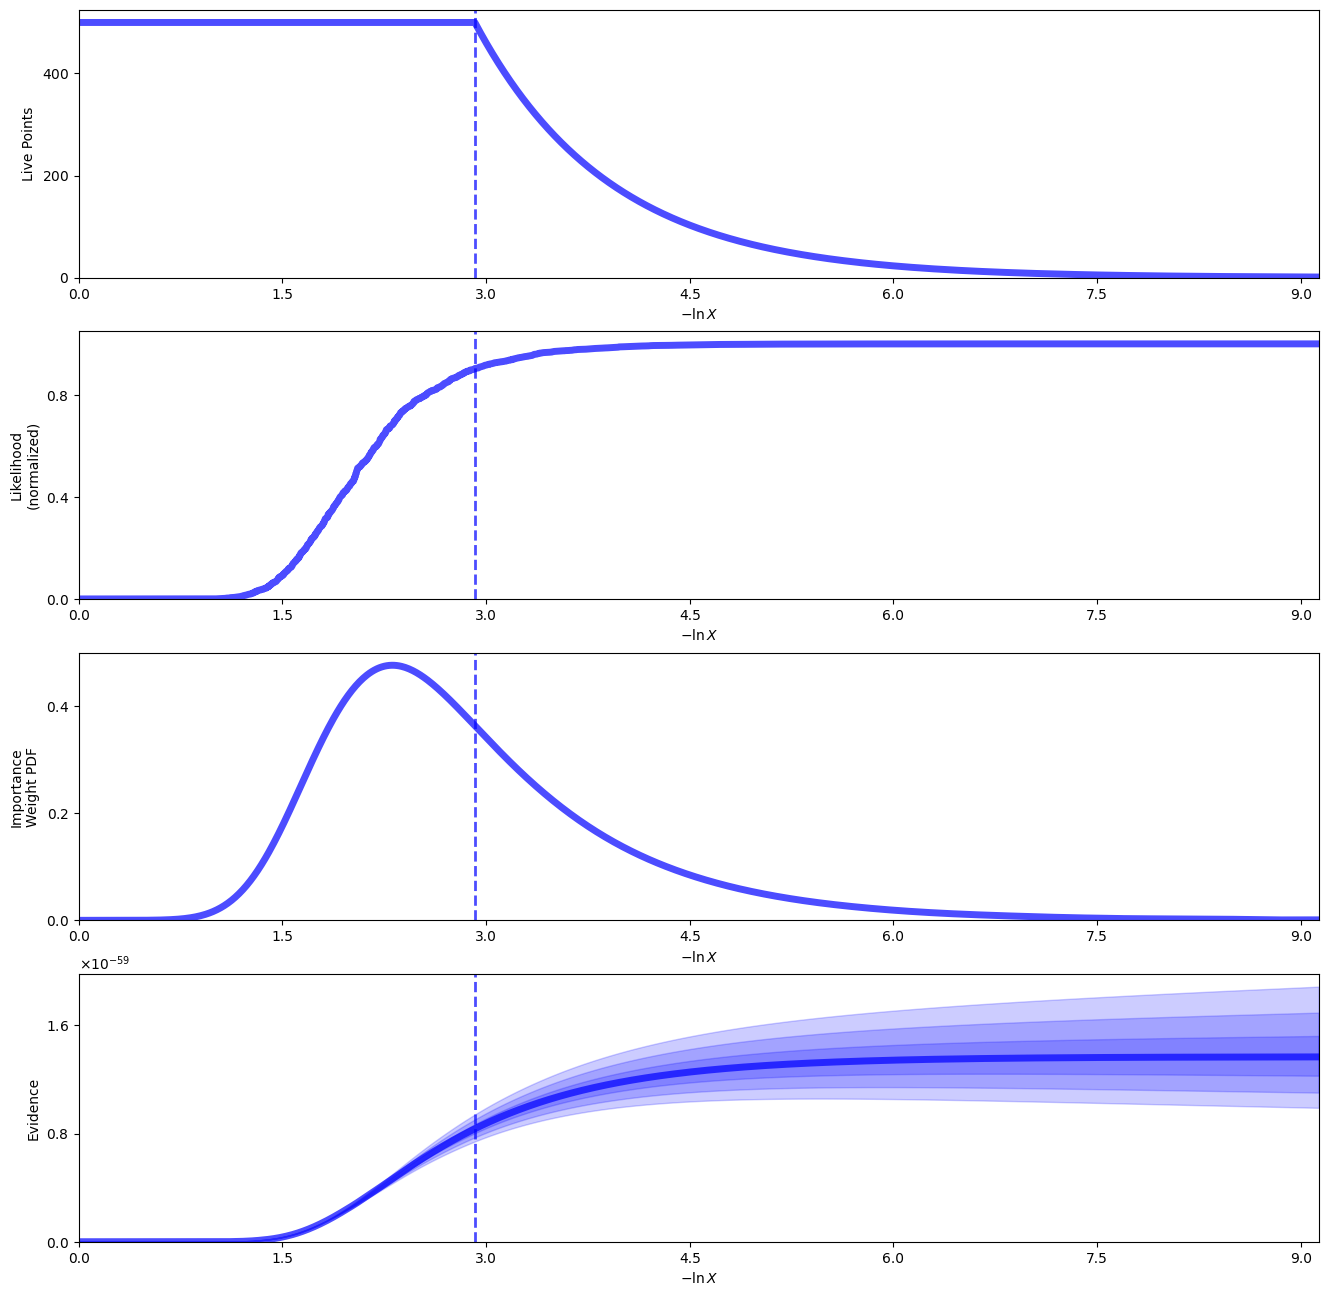

In [57]:
# Plot a summary of the run
r2fig, r2axes = dyplot.runplot(results_M2)

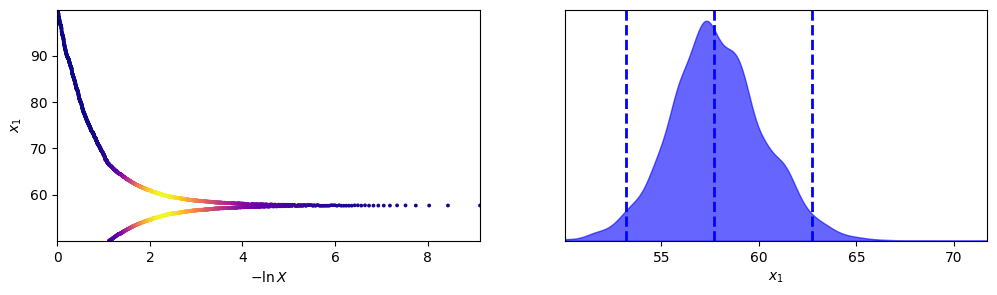

In [58]:
# Plot parameter traces and 1-D marginalized posteriors.
# On the left panels, you'll see that the live points started out scattered across the prior volume, then move inwards as the sampler climbs the likelihood
t2fig, t2axes = dyplot.traceplot(results_M2)

In [59]:
# Extract sampling results
samples_M2 = results_M2.samples  # samples
weights_M2 = np.exp(results_M2.logwt - results_M2.logz[-1])  # normalized weights

evidence_M2 = results_M2.logz[-1] # evidence
print(f"Bayesian evidence: {np.exp(evidence_M2): .3e}")

# Compute quantiles
quantiles_M2 = [dyfunc.quantile(samps, [0.05, 0.16, 0.84, 0.95], weights=weights_M2) for samps in samples_M2.T]

# Compute medians
medians_M2 = [dyfunc.quantile(samps, 0.5, weights=weights_M2) for samps in samples_M2.T]
medians_M2 = np.array(medians_M2).flatten()

print("ROBUST PARAMETERS ESTIMATION (using 90% parameter credible regions):")
print(f"H0 = {medians_M2[0]: .1f} +{quantiles_M2[0][3]-medians_M2[0]: .1f} -{medians_M2[0]-quantiles_M2[0][0]: .1f}")

# Compute weighted mean and covariance
mean_M2, cov_M2 = dyfunc.mean_and_cov(samples_M2, weights_M2)
print("MEAN AND STD PARAMETERS ESTIMATION:")
print(f"H0 = {mean_M2[0]: .1f} +-{np.sqrt(cov_M2[0,0]): .1f}")

Bayesian evidence:  1.367e-59
ROBUST PARAMETERS ESTIMATION (using 90% parameter credible regions):
H0 =  57.7 + 4.2 - 3.7
MEAN AND STD PARAMETERS ESTIMATION:
H0 =  57.8 +- 2.4


In [71]:
# dynesty can postprocess results to produce equally weighted samples.
# This is useful if you then want to used them in another package (for instance corner) that cannot deal with weights.
# Resample weighted samples
samples_equal_M2 = dyfunc.resample_equal(samples_M2, weights_M2)

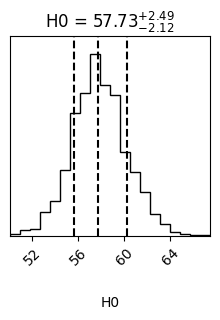

In [79]:
fig = corner.corner(samples_equal_M2, labels=["H0"], show_titles=True)
plt.axvline(medians_M2[0], color="k", linestyle="--")
plt.axvline(quantiles_M2[0][2], color="k", linestyle="--")
plt.axvline(quantiles_M2[0][1], color="k", linestyle="--")
plt.show()

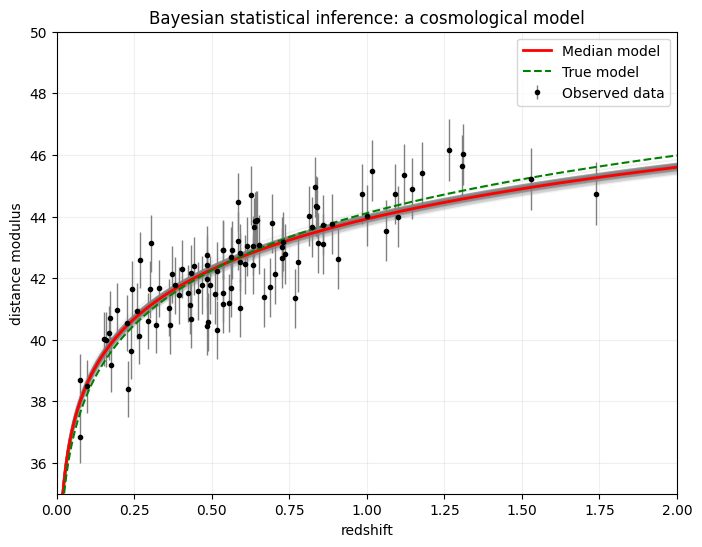

In [80]:
x_fit_M2 = np.linspace(0.01, 2, 1000)
y_median_M2 = new_model(x_fit_M2, medians_M2)

plt.figure(figsize=(8, 6))
# Plot the observed data
plt.errorbar(z_sample, mu_sample, yerr=dmu, fmt='.k', ecolor="gray", lw=1, label="Observed data")
# Plot a few random samples from posterior
for s in samples_equal_M2[np.random.choice(len(samples_equal_M2), size=100, replace=False)]:
  plt.plot(x_fit_M2, new_model(x_fit_M2, s), color='gray', alpha=0.1)
# Plot the median model
plt.plot(x_fit_M2, y_median_M2, lw=2, color="red", label="Median model")
# Plot the true model
plt.plot(z_grid, mu_true, '--', c='green', label="True model")

plt.xlabel("redshift")
plt.ylabel("distance modulus")
plt.title("Bayesian statistical inference: a cosmological model")
plt.legend()
plt.xlim(0, 2)
plt.ylim(35, 50)
plt.grid(alpha=0.2)
plt.show()

In [83]:
# Use Jeffreys scale for model comparison with the Bayes factor
bayes_factor = np.exp(evidence_M1 - evidence_M2)
print(f"Bayes factor: {bayes_factor: .0f}")
print("Jeffreys interpretation:")
if(bayes_factor<1):
  print("The strength of evidence in favor of model 1 is negative (the model 2 is supported)")
if(bayes_factor>=1 and bayes_factor<3):
  print("The strength of evidence in favor of model 1 is barely worth mentioning")
if(bayes_factor>=3 and bayes_factor<10):
  print("The strength of evidence in favor of model 1 is substantial")
if(bayes_factor>=10 and bayes_factor<30):
  print("The strength of evidence in favor of model 1 is strong")
if(bayes_factor>=30 and bayes_factor<100):
  print("The strength of evidence in favor of model 1 is very strong")
if(bayes_factor>=100):
  print("The strength of evidence in favor of model 1 is decisive")

Bayes factor:  2
Jeffreys interpretation:
The strength of evidence in favor of model 1 is barely worth mentioning


Do these data contain enough evidence of dark energy? No, they don't. Indeed, the Bayes factor is inconclusive.